In [1]:
# Standard setup cell - run before other cells.
import importlib.util
import subprocess
import sys
from pathlib import Path

def ensure_dependencies():
    required = {"numpy": "numpy", "matplotlib": "matplotlib", "pandas": "pandas"}
    missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_module_dir(start):
    for root in [start, *start.parents]:
        for candidate in (root, root / "Fuzzy Logic"):
            if (candidate / "membership.py").exists():
                return candidate
        if (root / ".git").exists():
            break
    return None

ensure_dependencies()
module_dir = find_module_dir(Path.cwd())
if module_dir is None and "google.colab" in sys.modules:
    clone_dir = Path("Modul-Praktikum-KK-RKA-25")
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/kcv-if/Modul-Praktikum-KK-RKA-25.git", str(clone_dir)], check=True)
    module_dir = find_module_dir(clone_dir)
if module_dir is None:
    raise RuntimeError("membership.py not found; open this notebook inside the repository")
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from membership import linear_up, linear_down, triangular, trapezoidal, sigmoid, phi
print("Python:", sys.version.split()[0])
print("Membership module:", module_dir / "membership.py")

Python: 3.10.0
Membership module: /Users/elyne/Desktop/AI Journey/ITS/Computational Intelligence/ComIn-5054251011-Maria-Putu-Evelyne-Corena-Puryatma-ModTask/Assignment/Mod Fuzzy/membership.py


In [2]:
def fuzzify_distance(distance):
    """Hitung derajat jarak pada domain praktikum 0 sampai 10 meter."""
    if not np.isfinite(distance) or not 0 <= distance <= 10:
        raise ValueError("Jarak harus berada pada domain 0-10 meter.")
    return {
        "dekat": linear_down(distance, 2, 4),
        "sedang": trapezoidal(distance, 1, 4, 6, 9),
        "jauh": linear_up(distance, 6, 8),
    }

def integrate_trapezoids(values, grid):
    # Luas setiap trapesium = lebar * rata-rata tinggi kedua ujung.
    return float(np.sum(np.diff(grid) * (values[:-1] + values[1:]) / 2))

def centroid(grid, membership):
    area = integrate_trapezoids(membership, grid)
    if area <= 0:
        raise ValueError("Tidak ada keluaran aktif; periksa domain dan cakupan aturan.")
    moment = integrate_trapezoids(grid * membership, grid)
    return moment / area

### Soal 1 - Pemahaman konsep

Pada jarak 3,5 m, model memberikan derajat dekat = 0,25 dan sedang ≈ 0,8333.

1. Jelaskan arti kedua derajat tersebut dengan kalimat Anda sendiri. Hubungkan penjelasan dengan posisi input pada grafik fungsi keanggotaan.
2. Seorang mahasiswa menganggap hasil itu salah karena jumlah derajatnya melebihi 1. Apakah Anda setuju? Berikan alasan berdasarkan definisi fungsi keanggotaan.
3. Bandingkan pernyataan "derajat dekat adalah 0,25" dengan "peluang jarak kurang dari 3 m adalah 25%". Informasi apa yang dijelaskan oleh masing-masing pernyataan?

In [3]:
'''
Soal 1 - Pemahaman konsep

1. Arti derajat pada 3,5 m
   - Dekat = 0,25   -> kurva dekat turun dari 1 (di 2 m) ke 0 (di 4 m).
                       3,5 m sudah hampir di ujung 4 m, jadi jarak ini hanya "sedikit dekat".
   - Sedang = 0,8333 -> kurva sedang naik dari 0 (di 1 m) ke 1 (di 4 m).
                       3,5 m sudah hampir sampai 4 m, jadi jarak ini "hampir sepenuhnya sedang".
   Kesimpulan: 3,5 m lebih cocok disebut sedang daripada dekat.

2. Tidak setuju.
   Setiap label punya fungsi keanggotaan sendiri dan dihitung terpisah.
   Syaratnya hanya: setiap derajat ada di antara 0 dan 1.
   Tidak ada aturan bahwa jumlah semua label harus 1,
   jadi 0,25 + 0,8333 = 1,0833 tetap sah.

3. Derajat bukan peluang
   - "Derajat dekat 0,25"           -> jaraknya SUDAH PASTI 3,5 m.
                                       Yang diukur: seberapa cocok 3,5 m dengan kata "dekat".
   - "Peluang jarak < 3 m adalah 25%" -> jaraknya BELUM PASTI.
                                       Yang diukur: seberapa mungkin jarak aslinya ternyata < 3 m.
   Fuzzy = batas katanya yang kabur, peluang = hasilnya yang belum diketahui.
'''

mu = fuzzify_distance(3.5)
print("Derajat pada 3,5 m      :", {label: round(v, 4) for label, v in mu.items()})
print("Semua derajat di [0, 1]?:", all(0 <= v <= 1 for v in mu.values()))
print("Jumlah derajat          :", round(sum(mu.values()), 4), "(boleh lebih dari 1)")

Derajat pada 3,5 m      : {'dekat': 0.25, 'sedang': 0.8333, 'jauh': 0.0}
Semua derajat di [0, 1]?: True
Jumlah derajat          : 1.0833 (boleh lebih dari 1)


### Soal 2 - Fuzzifikasi dan aktivasi aturan

![practice](img/Practice-Fuzzy-Logic.png)

| Label | Fungsi keanggotaan |
|---|---|
| Dekat | `linear_down(x, 2, 4)` |
| Sedang | `trapezoidal(x, 1, 4, 6, 9)` |
| Jauh | `linear_up(x, 6, 8)` |

1. Untuk setiap jarak, tentukan cabang rumus yang berlaku dan hitung ketiga derajat secara manual.
2. Susun tabel dengan kolom jarak, derajat dekat, derajat sedang, dan derajat jauh.
3. Gunakan aturan R1: dekat → kecepatan rendah; R2: sedang → kecepatan sedang; R3: jauh → kecepatan tinggi. Tentukan aturan aktif dan kekuatan aktivasinya untuk setiap jarak.
4. Verifikasi tabel menggunakan `fuzzify_distance`. Jika hasil berbeda, periksa kembali pemilihan cabang rumus dan pembulatannya.

In [4]:
'''
Soal 2 - Fuzzifikasi dan aktivasi aturan (jarak 2,5 m, sesuai gambar)

1. Hitung manual (cek dulu posisi x terhadap titik patah, baru pilih rumus)
   - Dekat  linear_down(x, 2, 4)       : 2 < 2,5 < 4 -> sisi turun
                                         (4 - 2,5) / (4 - 2) = 1,5 / 2 = 0,75
   - Sedang trapezoidal(x, 1, 4, 6, 9) : 1 < 2,5 < 4 -> sisi naik
                                         (2,5 - 1) / (4 - 1) = 1,5 / 3 = 0,5
   - Jauh   linear_up(x, 6, 8)         : 2,5 <= 6    -> bagian datar bawah
                                         = 0

2. Tabel derajat: lihat output di bawah
   (3,5 m ikut ditampilkan sebagai pembanding dari grafik di gambar).

3. Aktivasi aturan (tiap aturan hanya 1 syarat, jadi alpha = derajat labelnya)
   - R1 dekat  -> kecepatan rendah : alpha = 0,75 (aktif, paling kuat)
   - R2 sedang -> kecepatan sedang : alpha = 0,5  (aktif)
   - R3 jauh   -> kecepatan tinggi : alpha = 0    (tidak aktif)

4. Verifikasi dengan fuzzify_distance -> hasilnya sama dengan hitungan manual.
'''

manual = {"dekat": 0.75, "sedang": 0.5, "jauh": 0.0}

degree_rows = []
for x in [2.5, 3.5]:
    degree_rows.append({"jarak (m)": x, **fuzzify_distance(x)})
display(pd.DataFrame(degree_rows).round(4))

mu = fuzzify_distance(2.5)
rule_list = [("R1", "dekat", "rendah"), ("R2", "sedang", "sedang"), ("R3", "jauh", "tinggi")]
display(pd.DataFrame([
    {"aturan": name, "IF jarak": inp, "THEN kecepatan": out, "alpha": mu[inp], "aktif?": mu[inp] > 0}
    for name, inp, out in rule_list
]))

print("Hitungan manual sama dengan fuzzify_distance?",
      all(np.isclose(manual[label], mu[label]) for label in manual))

,jarak (m),dekat,sedang,jauh
0,2.5,0.75,0.5000,0.0
1,3.5,0.25,0.8333,0.0


,aturan,IF jarak,THEN kecepatan,alpha,aktif?
0,R1,dekat,rendah,0.75,True
1,R2,sedang,sedang,0.50,True
2,R3,jauh,tinggi,0.00,False


Hitungan manual sama dengan fuzzify_distance? True


### Soal 3 - Pengaruh perubahan parameter

Perancang mengubah fungsi dekat dari `linear_down(x, 2, 4)` menjadi `linear_down(x, 2, 5)`. Fungsi sedang, fungsi jauh, dan seluruh aturan tetap sama.

1. Prediksi pengaruh perubahan tersebut terhadap derajat dekat pada jarak 3,5 m. Tuliskan alasan sebelum menghitung.
2. Hitung derajat dekat dengan parameter lama dan baru, lalu bandingkan kekuatan aktivasi R1.
3. Gambarkan kedua fungsi dekat pada domain 0-6 m. Identifikasi bagian domain yang berubah dan yang tetap sama.
4. Apakah perubahan kekuatan R1 saja sudah cukup untuk menentukan angka kecepatan akhir? Jelaskan informasi atau tahap perhitungan yang masih perlu Anda periksa.

Derajat dekat pada 3,5 m -> lama: 0.25, baru: 0.50
Kekuatan R1 (alpha1)     -> lama: 0.25, baru: 0.50


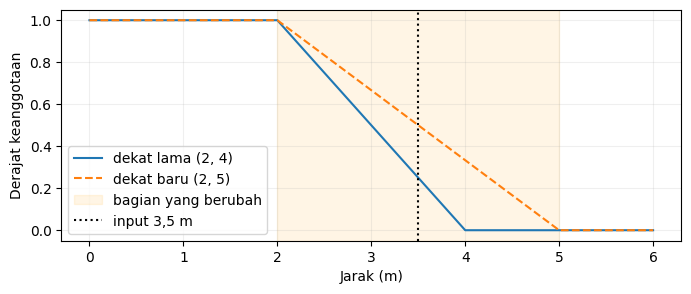

In [5]:
'''
Soal 3 - Pengaruh perubahan parameter

1. Prediksi
   Angka kedua (4 -> 5) adalah titik saat "dekat" menjadi 0.
   Garis turunnya jadi lebih panjang dan lebih landai, jadi turunnya lebih pelan.
   Maka pada 3,5 m derajat dekat akan NAIK.

2. Hitung
   - Lama: (4 - 3,5) / (4 - 2) = 0,5 / 2 = 0,25
   - Baru: (5 - 3,5) / (5 - 2) = 1,5 / 3 = 0,5
   Kekuatan R1 (alpha1) naik dari 0,25 menjadi 0,5 (2 kali lipat).

3. Grafik 0-6 m (lihat plot)
   - Tetap sama : 0-2 m (keduanya 1) dan 5-6 m (keduanya 0)
   - Berubah    : 2-5 m, kurva baru selalu lebih tinggi
                  (di 4-5 m kurva lama sudah 0, kurva baru masih > 0)

4. Belum cukup.
   alpha1 = 0,5 hanya menunjukkan seberapa kuat aturan R1 aktif, BUKAN kecepatan dalam m/s.
   Untuk mendapat angka kecepatan masih perlu:
   - fungsi keanggotaan output kecepatan (rendah, sedang, tinggi) dalam m/s,
   - kekuatan aturan lain (R2 = 0,8333 tetap ikut aktif),
   - implikasi (memotong kurva output dengan alpha),
   - agregasi (menggabungkan kurva semua aturan),
   - defuzzifikasi (misalnya centroid) -> baru menjadi angka m/s.
   Perkiraan: kecepatan akhir sedikit turun karena R1 (kecepatan rendah) jadi lebih kuat,
   tetapi besarnya baru diketahui setelah semua tahap di atas dihitung.
'''

old_dekat = linear_down(3.5, 2, 4)
new_dekat = linear_down(3.5, 2, 5)
print(f"Derajat dekat pada 3,5 m -> lama: {old_dekat:.2f}, baru: {new_dekat:.2f}")
print(f"Kekuatan R1 (alpha1)     -> lama: {old_dekat:.2f}, baru: {new_dekat:.2f}")

grid_0_6 = np.linspace(0, 6, 601)
plt.figure(figsize=(8, 3))
plt.plot(grid_0_6, [linear_down(x, 2, 4) for x in grid_0_6], label="dekat lama (2, 4)")
plt.plot(grid_0_6, [linear_down(x, 2, 5) for x in grid_0_6], "--", label="dekat baru (2, 5)")
plt.axvspan(2, 5, color="orange", alpha=0.1, label="bagian yang berubah")
plt.axvline(3.5, color="black", linestyle=":", label="input 3,5 m")
plt.xlabel("Jarak (m)")
plt.ylabel("Derajat keanggotaan")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

---
## Latihan Soal

Selesaikan tiga kasus berikut dengan **metode Mamdani**. Parameter dan aturan merupakan rancangan simulasi untuk latihan. Setiap kasus sudah menyediakan input crisp, domain, fungsi keanggotaan, serta basis aturan agar dapat diselesaikan sampai memperoleh output numerik.

**Ketentuan untuk semua kasus:** gunakan AND = min, OR = max, NOT = $1-\mu$, implikasi = min, agregasi = max, dan defuzzifikasi = centroid. Operator OR dan NOT digunakan jika tercantum pada aturan. Evaluasi fungsi keluaran hanya pada domain output yang diberikan.

Untuk setiap kasus, kerjakan tahapan berikut:

1. Gambarkan fungsi keanggotaan input dan output, lengkap dengan nama label dan satuannya.
2. Hitung fuzzifikasi input secara manual dan sajikan derajatnya dalam tabel.
3. Hitung kekuatan aktivasi setiap aturan; tunjukkan aturan yang aktif maupun tidak aktif.
4. Terapkan implikasi min pada kurva konsekuen setiap aturan, lalu gabungkan seluruh hasilnya dengan max.
5. Gambarkan kurva agregat dan hitung centroid menggunakan grid output dengan jarak antartitik **0,1**, termasuk kedua batas domain. Gunakan integrasi trapesium seperti fungsi `centroid` pada materi.
6. Sajikan output crisp dengan satuan yang sesuai, lalu jelaskan hubungannya dengan input dan aturan yang dominan.

Gunakan fungsi keanggotaan dari `membership.py` dan fungsi `centroid` yang telah tersedia. Susun perhitungan inferensi sesuai data setiap kasus. Tulis jawaban pada sel kosong; tambahkan sel Markdown atau kode jika diperlukan. Hint tersedia sebagai petunjuk pengerjaan tanpa jawaban akhir.

### Soal 1 - Kasus pengaturan kecepatan kipas

Sebuah pengendali menentukan persentase kecepatan kipas berdasarkan suhu ruangan. Pada saat pengukuran, suhu ruangan adalah **28°C**. Tentukan rekomendasi kecepatan kipas menggunakan seluruh tahapan Mamdani.

**Input:** suhu $T$ dengan domain [10,45] °C.

| Label suhu | Fungsi keanggotaan |
|---|---|
| Sejuk | `linear_down(T, 20, 30)` |
| Nyaman | `triangular(T, 20, 30, 40)` |
| Panas | `linear_up(T, 30, 40)` |

**Output:** kecepatan kipas $z$ dengan domain [0,100] persen dari kecepatan maksimum.

| Label kecepatan | Fungsi keanggotaan |
|---|---|
| Lambat | `linear_down(z, 0, 50)` |
| Sedang | `triangular(z, 25, 50, 75)` |
| Cepat | `linear_up(z, 50, 100)` |

**Basis aturan:**

| Aturan | Anteseden | Konsekuen |
|---|---|---|
| R1 | IF suhu Sejuk | THEN kecepatan Lambat |
| R2 | IF suhu Nyaman | THEN kecepatan Sedang |
| R3 | IF suhu Panas | THEN kecepatan Cepat |

Setelah menyelesaikan input 28°C, ulangi perhitungan untuk **36°C** dengan model yang sama. Bandingkan aturan aktif, bentuk kurva agregat, dan output crisp kedua kondisi. Jelaskan apakah perubahan rekomendasinya sesuai dengan maksud basis aturan.

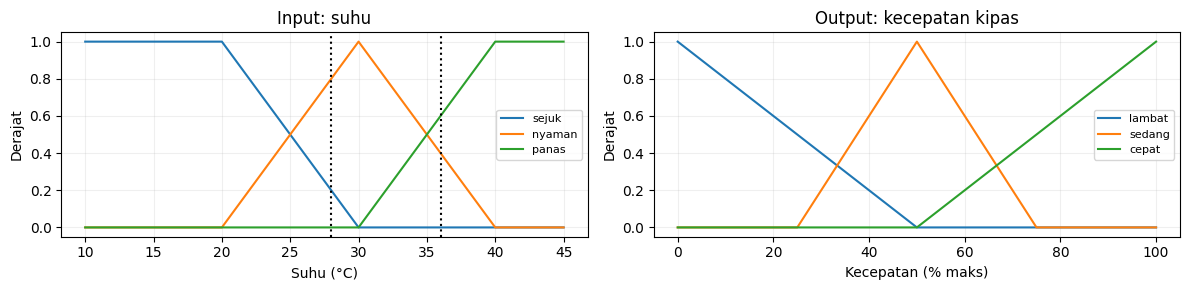

=== Suhu 28°C ===
Derajat suhu: {'sejuk': 0.2, 'nyaman': 0.8, 'panas': 0.0}


,aturan,anteseden,alpha,THEN,aktif?
0,R1,suhu sejuk,0.2,lambat,True
1,R2,suhu nyaman,0.8,sedang,True
2,R3,suhu panas,0.0,cepat,False


Rekomendasi kecepatan kipas: 43.25 %

=== Suhu 36°C ===
Derajat suhu: {'sejuk': 0.0, 'nyaman': 0.4, 'panas': 0.6}


,aturan,anteseden,alpha,THEN,aktif?
0,R1,suhu sejuk,0.0,lambat,False
1,R2,suhu nyaman,0.4,sedang,True
2,R3,suhu panas,0.6,cepat,True


Rekomendasi kecepatan kipas: 68.34 %



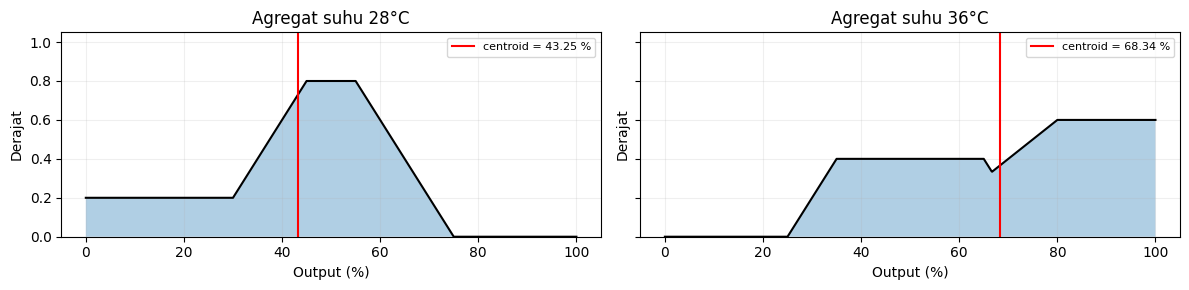

In [6]:
'''
Soal 1 - Kecepatan kipas (Mamdani)

Ketentuan: AND = min, OR = max, NOT = 1 - mu, implikasi = min, agregasi = max, centroid.
Grid output 0-100 % dengan jarak 0,1 (termasuk 0 dan 100).

Suhu 28°C 
Langkah 2 - Fuzzifikasi
- Sejuk  linear_down(T, 20, 30)    : 20 < 28 < 30 -> sisi turun -> (30 - 28) / 10 = 0,2
- Nyaman triangular(T, 20, 30, 40) : 20 < 28 < 30 -> sisi naik  -> (28 - 20) / 10 = 0,8
- Panas  linear_up(T, 30, 40)      : 28 <= 30     -> 0

Langkah 3 - Kekuatan aturan (1 syarat, jadi alpha = derajat label)
- R1 Sejuk  -> Lambat : 0,2 (aktif)
- R2 Nyaman -> Sedang : 0,8 (aktif, paling kuat)
- R3 Panas  -> Cepat  : 0   (tidak aktif)

Langkah 4-5 - Kurva Lambat dipotong di 0,2, kurva Sedang dipotong di 0,8,
lalu digabung dengan max. Centroid kurva gabungan = 43,25 %.

Langkah 6 - Rekomendasi: kipas ± 43,25 % dari kecepatan maksimum.
Aturan dominan R2 (nyaman -> sedang, puncak 50 %),
tapi R1 (lambat) menarik hasil sedikit ke bawah 50 %.

Suhu 36°C
- Sejuk  = 0                       (36 >= 30)
- Nyaman = (40 - 36) / 10 = 0,4    (sisi turun)
- Panas  = (36 - 30) / 10 = 0,6    (sisi naik)
- R1 = 0 (tidak aktif), R2 = 0,4, R3 = 0,6 (paling kuat)
Rekomendasi: kipas ± 68,34 %.

Perbandingan 
- 28°C: aktif R1 + R2, daerah agregat di kiri-tengah (0-75 %)   -> 43,25 %
- 36°C: aktif R2 + R3, daerah agregat geser ke kanan (25-100 %) -> 68,34 %
Suhu naik -> aturan "panas -> cepat" ikut aktif -> kipas lebih kencang.
Ini sesuai maksud basis aturan: makin panas ruangan, makin kencang kipasnya.
'''

# Fungsi bantu (dipakai lagi di Soal 2 dan Soal 3) 
def plot_mf(ax, funcs, grid, title, xlabel, marks=()):
    # Gambar beberapa fungsi keanggotaan dalam satu grafik
    for label, f in funcs.items():
        ax.plot(grid, [f(v) for v in grid], label=label)
    for m in marks:
        ax.axvline(m, color="black", linestyle=":")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Derajat")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

def mamdani(rule_alphas, out_funcs, grid):
    # rule_alphas: list (nama aturan, anteseden, alpha, label output)
    curves = {label: np.array([f(z) for z in grid]) for label, f in out_funcs.items()}
    clipped = [np.minimum(alpha, curves[out]) for _, _, alpha, out in rule_alphas]  # implikasi min
    agg = np.maximum.reduce(clipped)                                                # agregasi max
    return agg, centroid(grid, agg)                                                 # defuzzifikasi

def show_rules(rule_alphas):
    display(pd.DataFrame([
        {"aturan": name, "anteseden": ante, "alpha": round(alpha, 4), "THEN": out, "aktif?": alpha > 0}
        for name, ante, alpha, out in rule_alphas
    ]))

def plot_aggregated(ax, grid, agg, crisp, title, unit):
    ax.fill_between(grid, agg, alpha=0.35)
    ax.plot(grid, agg, color="black")
    ax.axvline(crisp, color="red", label=f"centroid = {crisp:.2f} {unit}")
    ax.set_title(title)
    ax.set_xlabel(f"Output ({unit})")
    ax.set_ylabel("Derajat")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

#  Model kipas 
temp_grid = np.linspace(10, 45, 351)
fan_grid = np.linspace(0, 100, 1001)   # jarak 0,1 termasuk 0 dan 100

suhu_mf = {
    "sejuk":  lambda T: linear_down(T, 20, 30),
    "nyaman": lambda T: triangular(T, 20, 30, 40),
    "panas":  lambda T: linear_up(T, 30, 40),
}
kipas_mf = {
    "lambat": lambda z: linear_down(z, 0, 50),
    "sedang": lambda z: triangular(z, 25, 50, 75),
    "cepat":  lambda z: linear_up(z, 50, 100),
}

def fan_case(T):
    mu = {label: f(T) for label, f in suhu_mf.items()}
    rule_alphas = [
        ("R1", "suhu sejuk",  mu["sejuk"],  "lambat"),
        ("R2", "suhu nyaman", mu["nyaman"], "sedang"),
        ("R3", "suhu panas",  mu["panas"],  "cepat"),
    ]
    agg, crisp = mamdani(rule_alphas, kipas_mf, fan_grid)
    return mu, rule_alphas, agg, crisp

# Langkah 1 - gambar fungsi input dan output
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
plot_mf(axes[0], suhu_mf, temp_grid, "Input: suhu", "Suhu (°C)", marks=[28, 36])
plot_mf(axes[1], kipas_mf, fan_grid, "Output: kecepatan kipas", "Kecepatan (% maks)")
plt.tight_layout()
plt.show()

# Langkah 2-6 untuk 28°C dan 36°C
fan_results = {}
for T in [28, 36]:
    mu, rule_alphas, agg, crisp = fan_case(T)
    fan_results[T] = (agg, crisp)
    print(f"=== Suhu {T}°C ===")
    print("Derajat suhu:", {label: round(v, 4) for label, v in mu.items()})
    show_rules(rule_alphas)
    print(f"Rekomendasi kecepatan kipas: {crisp:.2f} %\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
for ax, T in zip(axes, fan_results):
    plot_aggregated(ax, fan_grid, *fan_results[T], f"Agregat suhu {T}°C", "%")
plt.tight_layout()
plt.show()

### Soal 2 - Kasus penentuan durasi pencucian

Sebuah mesin cuci menentukan durasi pencucian dari tingkat kekotoran dan berat pakaian. Sensor menunjukkan **indeks kekotoran 65** dan **berat pakaian 6,5 kg**. Tentukan durasi pencucian dengan Mamdani menggunakan seluruh tahapan pada petunjuk latihan.

**Input pertama:** indeks kekotoran $k$ dengan domain [0,100]. Indeks 0 menyatakan tingkat kekotoran terendah dan 100 tertinggi; indeks ini tidak memiliki satuan fisik.

| Label kekotoran | Fungsi keanggotaan |
|---|---|
| Rendah | `linear_down(k, 20, 50)` |
| Sedang | `trapezoidal(k, 20, 40, 60, 80)` |
| Tinggi | `linear_up(k, 50, 80)` |

**Input kedua:** berat pakaian $b$ dengan domain [0,10] kg.

| Label berat | Fungsi keanggotaan |
|---|---|
| Ringan | `linear_down(b, 2, 5)` |
| Sedang | `triangular(b, 2, 5, 8)` |
| Berat | `linear_up(b, 5, 8)` |

**Output:** durasi pencucian $z$ dengan domain [0,60] menit.

| Label durasi | Fungsi keanggotaan |
|---|---|
| Singkat | `linear_down(z, 10, 30)` |
| Normal | `trapezoidal(z, 15, 25, 35, 45)` |
| Lama | `linear_up(z, 30, 50)` |

**Basis aturan:** setiap sel tabel menyatakan konsekuen untuk kombinasi **kekotoran AND berat pakaian**. Baris menunjukkan label kekotoran dan kolom menunjukkan label berat pakaian, sehingga terdapat sembilan aturan.

| Kekotoran / Berat pakaian | Ringan | Sedang | Berat |
|---|---|---|---|
| Rendah | Singkat | Singkat | Normal |
| Sedang | Singkat | Normal | Lama |
| Tinggi | Normal | Lama | Lama |

Beri nama R1-R9 secara berurutan dari kiri ke kanan pada setiap baris, mulai baris Rendah. Sajikan alpha untuk kesembilan aturan. Bila beberapa aturan memiliki konsekuen yang sama, tunjukkan bagaimana kontribusinya digabungkan.

Setelah memperoleh durasi untuk kondisi awal, ulangi perhitungan dengan **indeks kekotoran 35** dan berat tetap **6,5 kg**. Bandingkan kedua durasi dan jelaskan pengaruh perubahan input melalui aturan yang aktif.

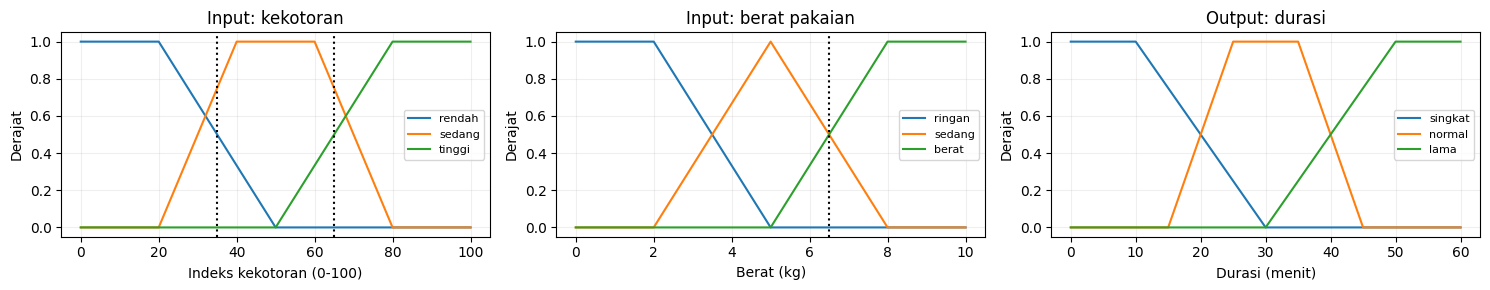

=== Kekotoran 65, berat 6,5 kg ===
Derajat kekotoran: {'rendah': 0.0, 'sedang': 0.75, 'tinggi': 0.5}
Derajat berat    : {'ringan': 0.0, 'sedang': 0.5, 'berat': 0.5}


,aturan,anteseden,alpha,THEN,aktif?
0,R1,kotor rendah AND berat ringan,0.0,singkat,False
1,R2,kotor rendah AND berat sedang,0.0,singkat,False
2,R3,kotor rendah AND berat berat,0.0,normal,False
3,R4,kotor sedang AND berat ringan,0.0,singkat,False
4,R5,kotor sedang AND berat sedang,0.5,normal,True
5,R6,kotor sedang AND berat berat,0.5,lama,True
6,R7,kotor tinggi AND berat ringan,0.0,normal,False
7,R8,kotor tinggi AND berat sedang,0.5,lama,True
8,R9,kotor tinggi AND berat berat,0.5,lama,True


Gabungan per label output (max): {'singkat': 0.0, 'normal': 0.5, 'lama': 0.5}
Durasi pencucian: 38.73 menit

=== Kekotoran 35, berat 6,5 kg ===
Derajat kekotoran: {'rendah': 0.5, 'sedang': 0.75, 'tinggi': 0.0}
Derajat berat    : {'ringan': 0.0, 'sedang': 0.5, 'berat': 0.5}


,aturan,anteseden,alpha,THEN,aktif?
0,R1,kotor rendah AND berat ringan,0.0,singkat,False
1,R2,kotor rendah AND berat sedang,0.5,singkat,True
2,R3,kotor rendah AND berat berat,0.5,normal,True
3,R4,kotor sedang AND berat ringan,0.0,singkat,False
4,R5,kotor sedang AND berat sedang,0.5,normal,True
5,R6,kotor sedang AND berat berat,0.5,lama,True
6,R7,kotor tinggi AND berat ringan,0.0,normal,False
7,R8,kotor tinggi AND berat sedang,0.0,lama,False
8,R9,kotor tinggi AND berat berat,0.0,lama,False


Gabungan per label output (max): {'singkat': 0.5, 'normal': 0.5, 'lama': 0.5}
Durasi pencucian: 30.00 menit



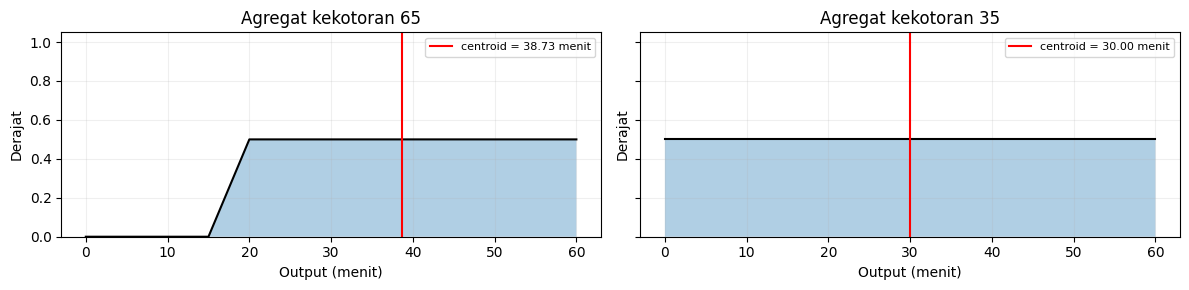

In [7]:
'''
Soal 2 - Durasi pencucian (Mamdani, 2 input digabung dengan AND)

Kondisi awal: kekotoran 65, berat 6,5 kg 
Langkah 2 - Fuzzifikasi
Kekotoran k = 65
- Rendah linear_down(k, 20, 50)         : 65 >= 50     -> 0
- Sedang trapezoidal(k, 20, 40, 60, 80) : 60 < 65 < 80 -> sisi turun -> (80 - 65) / 20 = 0,75
- Tinggi linear_up(k, 50, 80)           : 50 < 65 < 80 -> sisi naik  -> (65 - 50) / 30 = 0,5
Berat b = 6,5 kg
- Ringan linear_down(b, 2, 5)           : 6,5 >= 5     -> 0
- Sedang triangular(b, 2, 5, 8)         : 5 < 6,5 < 8  -> sisi turun -> (8 - 6,5) / 3 = 0,5
- Berat  linear_up(b, 5, 8)             : 5 < 6,5 < 8  -> sisi naik  -> (6,5 - 5) / 3 = 0,5

Langkah 3 - Kekuatan aturan: alpha = min(derajat kekotoran, derajat berat)
- R1 Rendah AND Ringan -> Singkat : min(0, 0)      = 0
- R2 Rendah AND Sedang -> Singkat : min(0, 0,5)    = 0
- R3 Rendah AND Berat  -> Normal  : min(0, 0,5)    = 0
- R4 Sedang AND Ringan -> Singkat : min(0,75, 0)   = 0
- R5 Sedang AND Sedang -> Normal  : min(0,75, 0,5) = 0,5
- R6 Sedang AND Berat  -> Lama    : min(0,75, 0,5) = 0,5
- R7 Tinggi AND Ringan -> Normal  : min(0,5, 0)    = 0
- R8 Tinggi AND Sedang -> Lama    : min(0,5, 0,5)  = 0,5
- R9 Tinggi AND Berat  -> Lama    : min(0,5, 0,5)  = 0,5

Aturan dengan konsekuen sama digabung lewat max di setiap titik (BUKAN dijumlah):
- Singkat : max(R1, R2, R4) = max(0, 0, 0)       = 0
- Normal  : max(R3, R5, R7) = max(0, 0,5, 0)     = 0,5
- Lama    : max(R6, R8, R9) = max(0,5, 0,5, 0,5) = 0,5
Karena kurvanya sama, hasilnya sama dengan memotong kurva itu di alpha terbesar.
Jadi Lama tetap dipotong di 0,5 (bukan 1,5).

Langkah 4-6 - Kurva Normal dan Lama dipotong di 0,5, lalu digabung dengan max.
Durasi pencucian ± 38,73 menit.
Hasilnya di antara Normal dan Lama, karena cucian cukup kotor dan cukup berat.

Kondisi kedua: kekotoran 35, berat 6,5 kg 
- Rendah = (50 - 35) / 30 = 0,5 | Sedang = (35 - 20) / 20 = 0,75 | Tinggi = 0
- Berat tetap: Ringan 0, Sedang 0,5, Berat 0,5
- Aktif: R2 Singkat 0,5 | R3 Normal 0,5 | R5 Normal 0,5 | R6 Lama 0,5
- Per label: Singkat 0,5 | Normal max(0,5, 0,5) = 0,5 | Lama 0,5
Kurva agregat jadi datar 0,5 di seluruh 0-60 menit, jadi centroidnya tepat di tengah:
Durasi pencucian = 30,00 menit.

Perbandingan 
- Kotor 65 -> 38,73 menit (aktif: Normal + Lama)
- Kotor 35 -> 30,00 menit (aktif: Singkat + Normal + Lama)
Kekotoran turun -> "tinggi" hilang, "rendah" muncul
-> R2 (Singkat) ikut aktif, R8 dan R9 (Lama) mati
-> hasil bergeser ke kiri, durasi lebih pendek ± 8,7 menit. Sesuai logika: cucian lebih bersih, cuci lebih sebentar.
'''

kotor_grid = np.linspace(0, 100, 1001)
berat_grid = np.linspace(0, 10, 101)
durasi_grid = np.linspace(0, 60, 601)   # jarak 0,1 termasuk 0 dan 60

kotor_mf = {
    "rendah": lambda k: linear_down(k, 20, 50),
    "sedang": lambda k: trapezoidal(k, 20, 40, 60, 80),
    "tinggi": lambda k: linear_up(k, 50, 80),
}
berat_mf = {
    "ringan": lambda b: linear_down(b, 2, 5),
    "sedang": lambda b: triangular(b, 2, 5, 8),
    "berat":  lambda b: linear_up(b, 5, 8),
}
durasi_mf = {
    "singkat": lambda z: linear_down(z, 10, 30),
    "normal":  lambda z: trapezoidal(z, 15, 25, 35, 45),
    "lama":    lambda z: linear_up(z, 30, 50),
}
# Tabel aturan: baris = kekotoran, kolom = berat (R1-R9 dari kiri ke kanan, mulai baris Rendah)
rule_table = {
    "rendah": {"ringan": "singkat", "sedang": "singkat", "berat": "normal"},
    "sedang": {"ringan": "singkat", "sedang": "normal",  "berat": "lama"},
    "tinggi": {"ringan": "normal",  "sedang": "lama",    "berat": "lama"},
}

def wash_case(k, b):
    mu_k = {label: f(k) for label, f in kotor_mf.items()}
    mu_b = {label: f(b) for label, f in berat_mf.items()}
    rule_alphas = []
    n = 1
    for lk in kotor_mf:
        for lb in berat_mf:
            alpha = min(mu_k[lk], mu_b[lb])   # AND = min
            rule_alphas.append((f"R{n}", f"kotor {lk} AND berat {lb}", alpha, rule_table[lk][lb]))
            n += 1
    agg, crisp = mamdani(rule_alphas, durasi_mf, durasi_grid)
    return mu_k, mu_b, rule_alphas, agg, crisp

# Langkah 1 - gambar fungsi input dan output
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
plot_mf(axes[0], kotor_mf, kotor_grid, "Input: kekotoran", "Indeks kekotoran (0-100)", marks=[65, 35])
plot_mf(axes[1], berat_mf, berat_grid, "Input: berat pakaian", "Berat (kg)", marks=[6.5])
plot_mf(axes[2], durasi_mf, durasi_grid, "Output: durasi", "Durasi (menit)")
plt.tight_layout()
plt.show()

# Langkah 2-6 untuk kekotoran 65 dan 35 (berat tetap 6,5 kg)
wash_results = {}
for k in [65, 35]:
    mu_k, mu_b, rule_alphas, agg, crisp = wash_case(k, 6.5)
    wash_results[k] = (agg, crisp)
    print(f"=== Kekotoran {k}, berat 6,5 kg ===")
    print("Derajat kekotoran:", {label: round(v, 4) for label, v in mu_k.items()})
    print("Derajat berat    :", {label: round(v, 4) for label, v in mu_b.items()})
    show_rules(rule_alphas)
    # Aturan dengan konsekuen sama -> ambil max (bukan dijumlah)
    per_label = {label: max(a for _, _, a, out in rule_alphas if out == label) for label in durasi_mf}
    print("Gabungan per label output (max):", per_label)
    print(f"Durasi pencucian: {crisp:.2f} menit\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
for ax, k in zip(axes, wash_results):
    plot_aggregated(ax, durasi_grid, *wash_results[k], f"Agregat kekotoran {k}", "menit")
plt.tight_layout()
plt.show()

### Soal 3 - Kasus pengaturan durasi penyiraman

Sebuah sistem penyiraman menentukan lama penyiraman dari kelembapan tanah dan suhu udara. Sensor menunjukkan **kelembapan tanah 45%** dan **suhu udara 32°C**. Tentukan durasi penyiraman dengan Mamdani. Kasus ini menggunakan AND, OR, dan NOT pada anteseden.

**Input pertama:** kelembapan tanah $h$ dengan domain [0,100] persen.

| Label kelembapan | Fungsi keanggotaan |
|---|---|
| Kering | `linear_down(h, 30, 60)` |
| Cukup | `trapezoidal(h, 30, 45, 60, 75)` |
| Basah | `linear_up(h, 60, 80)` |

**Input kedua:** suhu udara $T$ dengan domain [15,40] °C.

| Label suhu | Fungsi keanggotaan |
|---|---|
| Sejuk | `linear_down(T, 20, 30)` |
| Panas | `linear_up(T, 25, 35)` |

**Output:** durasi penyiraman $z$ dengan domain [0,30] menit.

| Label durasi | Fungsi keanggotaan |
|---|---|
| Singkat | `linear_down(z, 0, 15)` |
| Sedang | `triangular(z, 5, 15, 25)` |
| Lama | `linear_up(z, 15, 30)` |

**Basis aturan:**

| Aturan | Anteseden | Konsekuen |
|---|---|---|
| R1 | IF tanah Kering AND suhu Panas | THEN durasi Lama |
| R2 | IF tanah Kering AND NOT (suhu Panas) | THEN durasi Sedang |
| R3 | IF tanah Cukup AND suhu Panas | THEN durasi Sedang |
| R4 | IF tanah Cukup AND NOT (suhu Panas) | THEN durasi Singkat |
| R5 | IF tanah Basah OR suhu Sejuk | THEN durasi Singkat |

Selesaikan seluruh tahapan Mamdani dan tuliskan operasi anteseden setiap aturan secara eksplisit. Untuk R2 dan R4, NOT hanya diterapkan pada kondisi suhu Panas.

Kemudian ubah **suhu menjadi 27°C**, dengan kelembapan tetap **45%**. Hitung ulang hasilnya. Bandingkan kekuatan R2, R4, dan R5 serta jelaskan kontribusinya terhadap perubahan durasi. Berdasarkan fungsi yang diberikan, periksa pula apakah label Sejuk selalu sama dengan NOT Panas pada seluruh domain suhu.

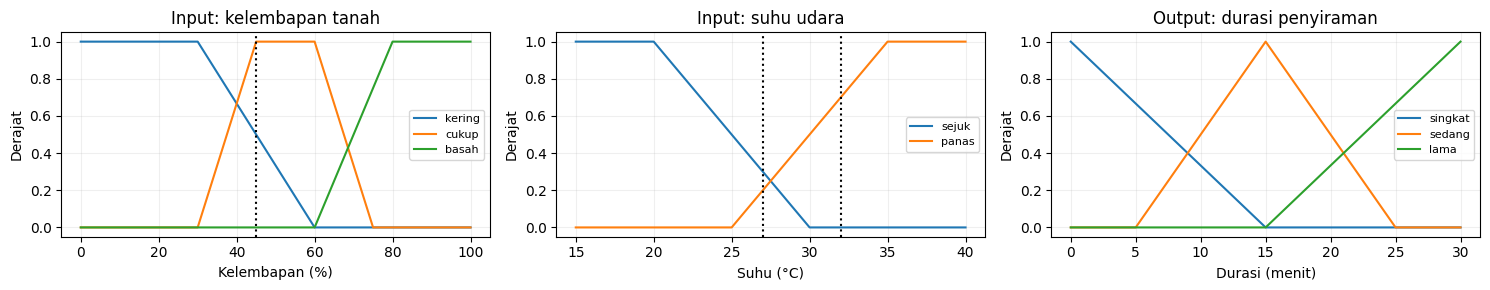

=== Kelembapan 45%, suhu 32°C ===
Derajat kelembapan: {'kering': 0.5, 'cukup': 1.0, 'basah': 0.0}
Derajat suhu      : {'sejuk': 0.0, 'panas': 0.7} | NOT panas: 0.3


,aturan,anteseden,alpha,THEN,aktif?
0,R1,kering AND panas,0.5,lama,True
1,R2,kering AND NOT(panas),0.3,sedang,True
2,R3,cukup AND panas,0.7,sedang,True
3,R4,cukup AND NOT(panas),0.3,singkat,True
4,R5,basah OR sejuk,0.0,singkat,False


Gabungan per label output (max): {'singkat': 0.3, 'sedang': 0.7, 'lama': 0.5}
Durasi penyiraman: 16.23 menit

=== Kelembapan 45%, suhu 27°C ===
Derajat kelembapan: {'kering': 0.5, 'cukup': 1.0, 'basah': 0.0}
Derajat suhu      : {'sejuk': 0.3, 'panas': 0.2} | NOT panas: 0.8


,aturan,anteseden,alpha,THEN,aktif?
0,R1,kering AND panas,0.2,lama,True
1,R2,kering AND NOT(panas),0.5,sedang,True
2,R3,cukup AND panas,0.2,sedang,True
3,R4,cukup AND NOT(panas),0.8,singkat,True
4,R5,basah OR sejuk,0.3,singkat,True


Gabungan per label output (max): {'singkat': 0.8, 'sedang': 0.5, 'lama': 0.2}
Durasi penyiraman: 11.71 menit



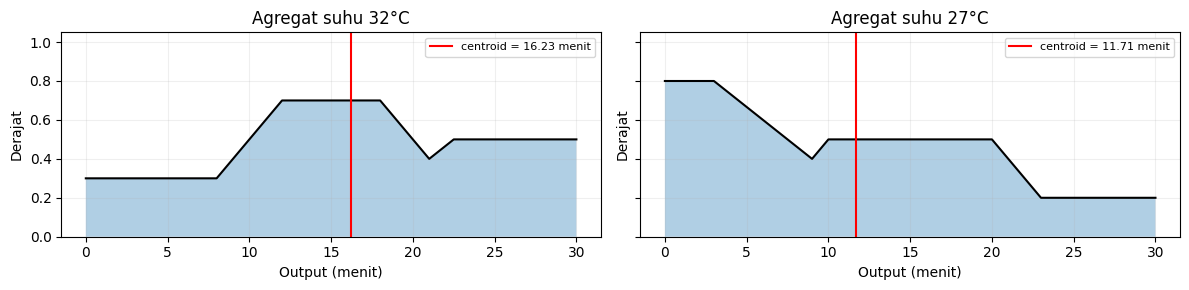

Sejuk == NOT Panas di semua suhu? False


,suhu (°C),sejuk,NOT panas
0,15,1.0,1.0
1,20,1.0,1.0
2,25,0.5,1.0
3,27,0.3,0.8
4,30,0.0,0.5
5,32,0.0,0.3
6,35,0.0,0.0
7,40,0.0,0.0


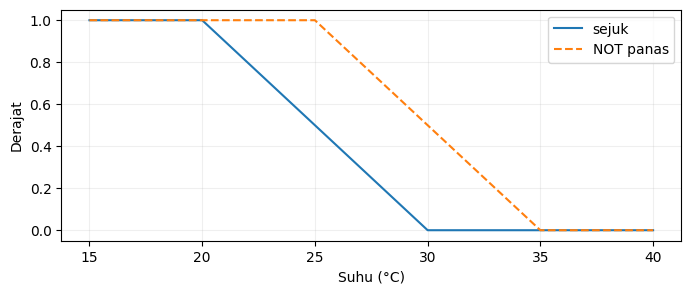

In [8]:
'''
Soal 3 - Durasi penyiraman (Mamdani dengan AND, OR, NOT)

Kondisi awal: kelembapan 45%, suhu 32°C
Langkah 2 - Fuzzifikasi
Kelembapan h = 45
- Kering linear_down(h, 30, 60)         : 30 < 45 < 60 -> (60 - 45) / 30 = 0,5
- Cukup  trapezoidal(h, 30, 45, 60, 75) : 45 = titik b -> 1
- Basah  linear_up(h, 60, 80)           : 45 <= 60     -> 0
Suhu T = 32
- Sejuk  linear_down(T, 20, 30)         : 32 >= 30     -> 0
- Panas  linear_up(T, 25, 35)           : 25 < 32 < 35 -> (32 - 25) / 10 = 0,7
- NOT Panas = 1 - 0,7 = 0,3

Langkah 3 - Kekuatan aturan
- R1 Kering AND Panas     -> Lama    : min(0,5, 0,7) = 0,5
- R2 Kering AND NOT Panas -> Sedang  : min(0,5, 0,3) = 0,3
- R3 Cukup AND Panas      -> Sedang  : min(1, 0,7)   = 0,7
- R4 Cukup AND NOT Panas  -> Singkat : min(1, 0,3)   = 0,3
- R5 Basah OR Sejuk       -> Singkat : max(0, 0)     = 0 (tidak aktif)
Gabungan per label (max): Singkat 0,3 | Sedang max(0,3, 0,7) = 0,7 | Lama 0,5

Langkah 4-6 - Potong tiap kurva output, gabung dengan max, hitung centroid.
Durasi penyiraman ± 16,23 menit.
Dominan R3 (tanah cukup + panas -> sedang, puncak 15 menit), ditarik sedikit ke atas oleh R1 (lama).

Kondisi kedua: kelembapan 45%, suhu 27°C 
- Kering 0,5, Cukup 1, Basah 0 (tidak berubah)
- Sejuk = (30 - 27) / 10 = 0,3 | Panas = (27 - 25) / 10 = 0,2 | NOT Panas = 0,8
- R1 = min(0,5, 0,2) = 0,2 | R2 = min(0,5, 0,8) = 0,5 | R3 = min(1, 0,2) = 0,2
- R4 = min(1, 0,8)   = 0,8 | R5 = max(0, 0,3)   = 0,3
Gabungan per label: Singkat max(0,8, 0,3) = 0,8 | Sedang max(0,5, 0,2) = 0,5 | Lama 0,2
Durasi penyiraman ± 11,71 menit.

Perbandingan R2, R4, R5
Aturan | 32°C | 27°C | Efek
R2     | 0,3  | 0,5  | Sedang sedikit lebih kuat
R4     | 0,3  | 0,8  | Singkat jauh lebih kuat -> jadi paling dominan
R5     | 0    | 0,3  | Ikut aktif, tapi kalah dari R4 di label Singkat (max ambil 0,8)
Suhu turun -> "panas" melemah, "NOT panas" menguat -> R4 (singkat) mendominasi
-> durasi turun dari 16,23 menjadi 11,71 menit.
Masuk akal: udara lebih sejuk, tanaman butuh air lebih sedikit.

Apakah Sejuk = NOT Panas?
Tidak.
- Sejuk     = linear_down(T, 20, 30)     -> turun dari 20 ke 30 °C
- NOT Panas = 1 - linear_up(T, 25, 35)   -> turun dari 25 ke 35 °C
Kurvanya bergeser 5 °C. Contoh di 27°C: Sejuk = 0,3 tapi NOT Panas = 0,8.
Keduanya hanya sama di 15-20 °C (keduanya 1) dan 35-40 °C (keduanya 0).
Jadi walaupun maknanya mirip dalam bahasa sehari-hari, sebagai fungsi keduanya berbeda.
'''

lembap_grid = np.linspace(0, 100, 1001)
suhu_grid = np.linspace(15, 40, 251)
siram_grid = np.linspace(0, 30, 301)   # jarak 0,1 termasuk 0 dan 30

lembap_mf = {
    "kering": lambda h: linear_down(h, 30, 60),
    "cukup":  lambda h: trapezoidal(h, 30, 45, 60, 75),
    "basah":  lambda h: linear_up(h, 60, 80),
}
udara_mf = {
    "sejuk": lambda T: linear_down(T, 20, 30),
    "panas": lambda T: linear_up(T, 25, 35),
}
siram_mf = {
    "singkat": lambda z: linear_down(z, 0, 15),
    "sedang":  lambda z: triangular(z, 5, 15, 25),
    "lama":    lambda z: linear_up(z, 15, 30),
}

def water_case(h, T):
    mu_h = {label: f(h) for label, f in lembap_mf.items()}
    mu_t = {label: f(T) for label, f in udara_mf.items()}
    not_panas = 1 - mu_t["panas"]   # NOT = 1 - mu
    rule_alphas = [
        ("R1", "kering AND panas",      min(mu_h["kering"], mu_t["panas"]), "lama"),
        ("R2", "kering AND NOT(panas)", min(mu_h["kering"], not_panas),     "sedang"),
        ("R3", "cukup AND panas",       min(mu_h["cukup"],  mu_t["panas"]), "sedang"),
        ("R4", "cukup AND NOT(panas)",  min(mu_h["cukup"],  not_panas),     "singkat"),
        ("R5", "basah OR sejuk",        max(mu_h["basah"],  mu_t["sejuk"]), "singkat"),
    ]
    agg, crisp = mamdani(rule_alphas, siram_mf, siram_grid)
    return mu_h, mu_t, not_panas, rule_alphas, agg, crisp

# Langkah 1 - gambar fungsi input dan output
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
plot_mf(axes[0], lembap_mf, lembap_grid, "Input: kelembapan tanah", "Kelembapan (%)", marks=[45])
plot_mf(axes[1], udara_mf, suhu_grid, "Input: suhu udara", "Suhu (°C)", marks=[32, 27])
plot_mf(axes[2], siram_mf, siram_grid, "Output: durasi penyiraman", "Durasi (menit)")
plt.tight_layout()
plt.show()

# Langkah 2-6 untuk suhu 32°C dan 27°C (kelembapan tetap 45%)
water_results = {}
for T in [32, 27]:
    mu_h, mu_t, not_panas, rule_alphas, agg, crisp = water_case(45, T)
    water_results[T] = (agg, crisp)
    print(f"=== Kelembapan 45%, suhu {T}°C ===")
    print("Derajat kelembapan:", {label: round(v, 4) for label, v in mu_h.items()})
    print("Derajat suhu      :", {label: round(v, 4) for label, v in mu_t.items()}, "| NOT panas:", round(not_panas, 4))
    show_rules(rule_alphas)
    per_label = {label: round(max(a for _, _, a, out in rule_alphas if out == label), 4) for label in siram_mf}
    print("Gabungan per label output (max):", per_label)
    print(f"Durasi penyiraman: {crisp:.2f} menit\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
for ax, T in zip(axes, water_results):
    plot_aggregated(ax, siram_grid, *water_results[T], f"Agregat suhu {T}°C", "menit")
plt.tight_layout()
plt.show()

# Cek: apakah Sejuk sama dengan NOT Panas di seluruh domain suhu?
sejuk_curve = np.array([udara_mf["sejuk"](T) for T in suhu_grid])
not_panas_curve = 1 - np.array([udara_mf["panas"](T) for T in suhu_grid])
print("Sejuk == NOT Panas di semua suhu?", bool(np.allclose(sejuk_curve, not_panas_curve)))
display(pd.DataFrame([
    {"suhu (°C)": T, "sejuk": udara_mf["sejuk"](T), "NOT panas": 1 - udara_mf["panas"](T)}
    for T in [15, 20, 25, 27, 30, 32, 35, 40]
]).round(4))

plt.figure(figsize=(8, 3))
plt.plot(suhu_grid, sejuk_curve, label="sejuk")
plt.plot(suhu_grid, not_panas_curve, "--", label="NOT panas")
plt.xlabel("Suhu (°C)")
plt.ylabel("Derajat")
plt.legend()
plt.grid(alpha=0.2)
plt.show()